> **Chapter 13, Part 7** | Continues from [13.6 The Translation Cascade](13.6%20The%20Translation%20Cascade.ipynb). **Focus:** assemble 13.1 through 13.6 into one printable diagnostic for your environment.

# Capstone Lab: Build Your Own Governance Pressure Map

This notebook is the apparatus turned outward. The reader provides a free-text description of a governance situation (their environment, an incident they observed, a regulatory transition they are managing). The capstone runs the parser from 13.5 (or its mock fallback), uses the result to seed pressure decompositions across scales, and renders a pressure heatmap, decoupling lens, and translation drift estimate alongside a printable summary.

The lab is opinionated about output: by the end of execution, the reader has a one-page diagnostic they can paste into a status update or a remediation plan.


In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from enum import Enum
from typing import List, Dict
import os
import re


# Re-declare types so this notebook is self-contained even if run alone.
class Scale(str, Enum):
    FIELD = 'field'
    FIRM = 'firm'
    DIVISION = 'division'
    TEAM = 'team'
    PRACTITIONER = 'practitioner'

SCALE_ORDER = [Scale.FIELD, Scale.FIRM, Scale.DIVISION, Scale.TEAM, Scale.PRACTITIONER]


@dataclass
class PressureVector:
    coercive: float
    mimetic: float
    normative: float
    scale: Scale
    evidence: List[str] = field(default_factory=list)

    def __post_init__(self):
        self.coercive = float(np.clip(self.coercive, 0.0, 1.0))
        self.mimetic = float(np.clip(self.mimetic, 0.0, 1.0))
        self.normative = float(np.clip(self.normative, 0.0, 1.0))


@dataclass
class GovernanceIncident:
    summary: str
    scales: List[str] = field(default_factory=list)
    dominant_pressure: str = 'unknown'
    suggested_control: str = ''
    confidence: float = 0.0
    citations: List[str] = field(default_factory=list)


SCALE_KEYWORDS = {
    'field': ['regulator', 'legislation', 'directive', 'industry-wide', 'eu ', 'sec ', 'occ ', 'sox', 'dora'],
    'firm': ['firm', 'company', 'organization', 'enterprise', 'corporate', 'firm-wide'],
    'division': ['division', 'business unit', 'practice', 'sector'],
    'team': ['team', 'project', 'engagement', 'pod', 'squad'],
    'practitioner': ['individual', 'practitioner', 'analyst', 'engineer', 'consultant', 'me ', 'i ', 'personally'],
}
PRESSURE_KEYWORDS = {
    'coercive': ['regulation', 'audit', 'mandate', 'must', 'required', 'compliance', 'contract'],
    'mimetic': ['benchmark', 'peer', 'competitor', 'industry standard', 'best practice'],
    'normative': ['certification', 'training', 'professional', 'ethics', 'code of conduct', 'cdmp'],
}


def parse_incident(text: str) -> GovernanceIncident:
    """Mock parser, identical structure to the LLM parser in 13.5."""
    t = text.lower()
    scales = [s for s, kws in SCALE_KEYWORDS.items() if any(k in t for k in kws)]
    scores = {p: sum(1 for k in kws if k in t) for p, kws in PRESSURE_KEYWORDS.items()}
    dominant = max(scores, key=scores.get) if any(scores.values()) else 'unknown'
    controls = {
        'coercive': 'Add a documented control mapped to the cited regulation; assign owner; record evidence.',
        'mimetic': 'Run a peer benchmark; codify the chosen practice as a firm-wide standard.',
        'normative': 'Update training and certification expectations; align with professional code.',
        'unknown': 'Restate the incident with explicit pressure attribution before proceeding.',
    }
    return GovernanceIncident(
        summary=text.strip()[:240],
        scales=scales,
        dominant_pressure=dominant,
        suggested_control=controls[dominant],
        confidence=0.4 + 0.1 * sum(1 for v in scores.values() if v > 0),
        citations=['Mock parser (13.7 capstone, deterministic fallback)'],
    )


def seed_pressure_field_from_incident(incident: GovernanceIncident) -> List[PressureVector]:
    """Translate a parsed incident into a baseline pressure decomposition.

    Heuristic: place the dominant pressure heaviest at the scales surfaced by the
    parser, then taper to other scales. This is not a measurement; it is a starting
    point the user is expected to refine.
    """
    scale_set = set(incident.scales)
    out = []
    for scale in SCALE_ORDER:
        c = m = n = 0.20
        if scale.value in scale_set:
            if incident.dominant_pressure == 'coercive':
                c = 0.85
            elif incident.dominant_pressure == 'mimetic':
                m = 0.80
            elif incident.dominant_pressure == 'normative':
                n = 0.80
        # Apply the field-firm-practitioner asymmetry from 13.1 mildly.
        if scale == Scale.FIELD:
            c = max(c, 0.55)
        if scale == Scale.PRACTITIONER:
            n = max(n, 0.55)
        out.append(PressureVector(coercive=c, mimetic=m, normative=n, scale=scale,
                                  evidence=[f'seeded from incident: {incident.dominant_pressure}']))
    return out


In [2]:
# The reader's input. Edit the text below to match an environment you care about.
USER_INCIDENT_TEXT = (
    'Our consulting practice serves regional banks. Last quarter, an OCC audit '
    'flagged us because the firm-wide model risk inventory missed three production '
    'models that engagement teams had spun up in shadow Snowflake accounts. Two '
    'peer firms recently announced centralized model registries. Several individual '
    'data scientists hold CDMP certifications and feel personally accountable for '
    'documentation, but the SOPs do not require it.'
)

incident = parse_incident(USER_INCIDENT_TEXT)
print('--- Parsed governance incident ---')
print(json.dumps(incident.__dict__, indent=2))

field_seeded = seed_pressure_field_from_incident(incident)
print('\n--- Seeded pressure field ---')
for v in field_seeded:
    print(f'  {v.scale.value:>13s}: c={v.coercive:.2f} m={v.mimetic:.2f} n={v.normative:.2f}')


--- Parsed governance incident ---
{
  "summary": "Our consulting practice serves regional banks. Last quarter, an OCC audit flagged us because the firm-wide model risk inventory missed three production models that engagement teams had spun up in shadow Snowflake accounts. Two peer firms re",
  "scales": [
    "field",
    "firm",
    "division",
    "team",
    "practitioner"
  ],
  "dominant_pressure": "normative",
  "suggested_control": "Update training and certification expectations; align with professional code.",
  "confidence": 0.7000000000000001,
  "citations": [
    "Mock parser (13.7 capstone, deterministic fallback)"
  ]
}

--- Seeded pressure field ---
          field: c=0.55 m=0.20 n=0.80
           firm: c=0.20 m=0.20 n=0.80
       division: c=0.20 m=0.20 n=0.80
           team: c=0.20 m=0.20 n=0.80
   practitioner: c=0.20 m=0.20 n=0.80


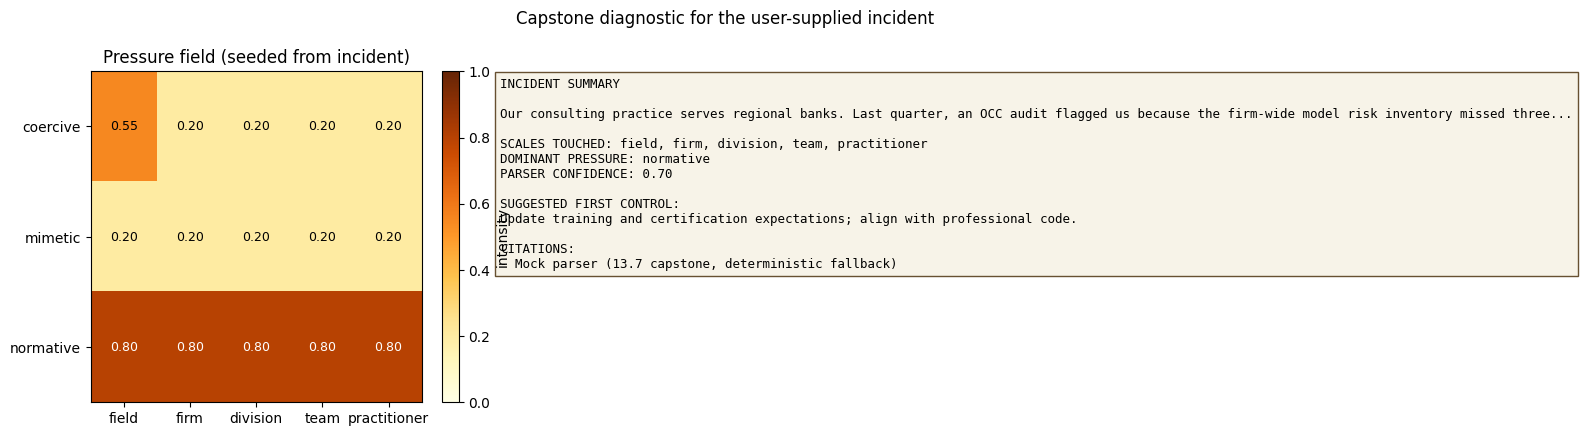

In [3]:
def render_capstone(field_seeded, incident, title='Capstone diagnostic'):
    matrix = np.stack([np.array([v.coercive, v.mimetic, v.normative]) for v in field_seeded], axis=1)
    scales = [v.scale.value for v in field_seeded]
    mechanisms = ['coercive', 'mimetic', 'normative']

    fig, axes = plt.subplots(1, 2, figsize=(14.6, 4.4),
                             gridspec_kw={'width_ratios': [1.5, 1]})
    ax = axes[0]
    im = ax.imshow(matrix, aspect='auto', cmap='YlOrBr', vmin=0, vmax=1)
    ax.set_xticks(range(len(scales)))
    ax.set_xticklabels(scales)
    ax.set_yticks(range(len(mechanisms)))
    ax.set_yticklabels(mechanisms)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, f'{matrix[i, j]:.2f}', ha='center', va='center',
                    color='black' if matrix[i, j] < 0.6 else 'white', fontsize=9)
    ax.set_title('Pressure field (seeded from incident)')
    fig.colorbar(im, ax=ax, label='intensity')

    ax2 = axes[1]
    ax2.axis('off')
    summary_lines = [
        f'INCIDENT SUMMARY',
        f'',
        incident.summary[:140] + ('...' if len(incident.summary) > 140 else ''),
        '',
        f'SCALES TOUCHED: {", ".join(incident.scales) if incident.scales else "(none parsed)"}',
        f'DOMINANT PRESSURE: {incident.dominant_pressure}',
        f'PARSER CONFIDENCE: {incident.confidence:.2f}',
        '',
        f'SUGGESTED FIRST CONTROL:',
        incident.suggested_control,
        '',
        f'CITATIONS:',
    ] + [f'- {c}' for c in incident.citations]
    ax2.text(0.02, 0.98, '\n'.join(summary_lines), transform=ax2.transAxes,
             fontsize=9, ha='left', va='top', family='monospace',
             bbox=dict(facecolor='#f7f2e7', edgecolor='#5a4220', alpha=0.92))
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


render_capstone(field_seeded, incident, title='Capstone diagnostic for the user-supplied incident')


## Reading the diagnostic

The capstone produces a one-page picture: a pressure heatmap on the left, a textual summary on the right. The heatmap encodes scale and mechanism. The summary encodes provenance and recommended action. Print or screen-grab the figure; paste it into the next steering committee deck.

The diagnostic is **not** a measurement. The pressure intensities are seeded heuristics, the parser is the mock implementation when no Anthropic key is present, and there is no validation against trained human coders. The diagnostic is a triage tool. Its honest use case is: when an incident arrives, run it through this capstone before drafting the response, and the apparatus will surface the scale and mechanism the response should target.

## Where this connects

- **13.1** seeds the pressure types and the scale enum. The capstone reuses both.
- **13.5** provides the parser. The capstone uses the mock implementation for portability; replacing `parse_incident` with `LLMParser().parse` is one line of code.
- **13.6** provides the cascade complement. A real diagnostic would also draft the four-layer cascade for the incident; that step is left as an exercise (it is one cell, using the cascade infrastructure from 13.6).

## Practical implications

- **For practitioners:** edit `USER_INCIDENT_TEXT` to your environment; rerun; capture the figure. That is the workflow.
- **For researchers:** the capstone is the user-facing surface for the validation study described in the research plan. A practitioner cohort running it against described incidents, with the parser in live mode, produces the data needed to validate the parser against human coding.
- **For students:** the capstone is an exercise in composition. Three components from earlier notebooks compose into one diagnostic without conceptual additions.
